In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/faizanhaider01/placement-u/placement.csv


In [2]:
import tensorflow
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
from mlxtend.plotting import plot_decision_regions

In [4]:
df = pd.read_csv('/kaggle/input/datasets/faizanhaider01/placement-u/placement.csv')

In [5]:
df.sample(4)

,cgpa,iq,placement
63,6.3,128,1
86,5.1,128,0
40,4.9,134,0
14,6.1,103,0


In [6]:
X = df.iloc[:,0:2]
y =df.iloc[:,-1]

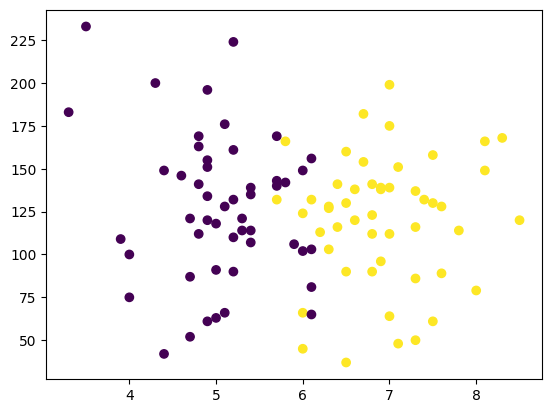

In [7]:
plt.scatter(df['cgpa'],df['iq'],c=y)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [9]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transfom(X_train)
# X_test_scaled = scaler.transform(X_test)

In [10]:
model = Sequential()

model.add(Dense(8, input_dim=2, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-01 11:46:31.958261: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [11]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [12]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=35, verbose=1)

Epoch 1/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.5125 - loss: 3.8913 - val_accuracy: 0.4500 - val_loss: 4.1335
Epoch 2/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5125 - loss: 3.4128 - val_accuracy: 0.4500 - val_loss: 3.6062
Epoch 3/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5125 - loss: 2.9795 - val_accuracy: 0.4500 - val_loss: 3.0764
Epoch 4/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5125 - loss: 2.5172 - val_accuracy: 0.4500 - val_loss: 2.5523
Epoch 5/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5125 - loss: 2.0659 - val_accuracy: 0.4500 - val_loss: 2.0381
Epoch 6/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5125 - loss: 1.6557 - val_accuracy: 0.4500 - val_loss: 1.5472
Epoch 7/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5125 - loss: 1.2303 - val_accuracy: 0.4500 - val_loss: 1.1208
Epoch 8/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5125 - loss: 0.9172 - val_accuracy: 0.4500 - val_loss: 0.8116

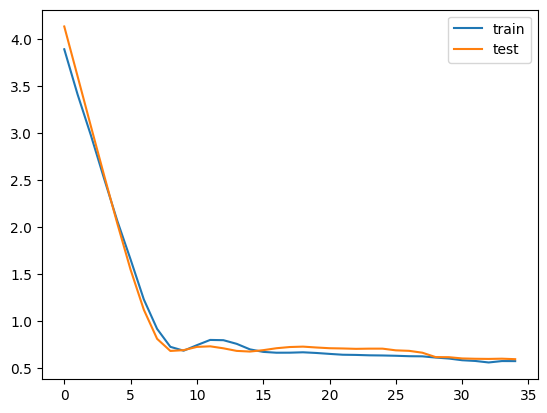

In [13]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [14]:
# plot_decision_regions(X_test.values, y_test.ravel(), clf = model, legend=2)
# plt.show()

# EARLY STOPING:

In [15]:

model.add(Dense(8, input_dim=2, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [17]:
callback = EarlyStopping(
    monitor = 'val_loss',
    min_delta = 0.0001,
    patience = 2,
    verbose = 1,
    mode = 'auto',
    baseline = None,
    restore_best_weights  =True
)

In [18]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=35, callbacks=callback)

Epoch 1/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step - accuracy: 0.5125 - loss: 0.7044 - val_accuracy: 0.4500 - val_loss: 0.7085
Epoch 2/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5125 - loss: 0.7008 - val_accuracy: 0.4500 - val_loss: 0.7048
Epoch 3/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5125 - loss: 0.6967 - val_accuracy: 0.4500 - val_loss: 0.7013
Epoch 4/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5125 - loss: 0.6941 - val_accuracy: 0.4500 - val_loss: 0.6996
Epoch 5/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5125 - loss: 0.6933 - val_accuracy: 0.4500 - val_loss: 0.6987
Epoch 6/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5125 - loss: 0.6932 - val_accuracy: 0.4500 - val_loss: 0.6979
Epoch 7/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6976
Epoch 8/35
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5125 - loss: 0.6929 - val_accuracy: 0.4500 - val_loss: 0.6975

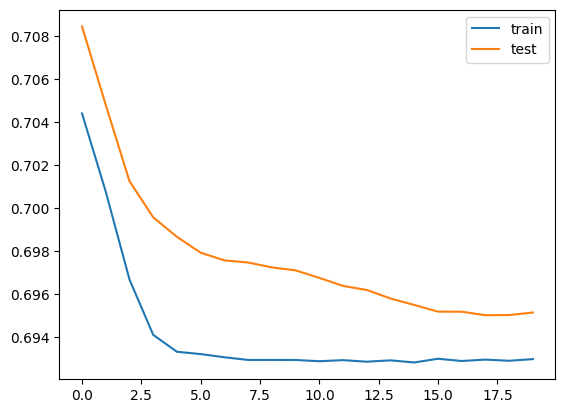

In [19]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()